In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df = df.rename(columns={
    "Sibsp": "No_Sibsp_onboard",
    "Parch": "No_Children_Siblings_onboard",
    "Ticket": "Ticket_number",
    "Fare": "Passenger_fare",
    "Cabin": "Cabin_no",
    "Embarked": "Port_of_Embarkation",
    "Pclass": "Ticket_class",
    "PassengerId": "Passenger_ID"
})

In [8]:
df.columns

Index(['Passenger_ID', 'Survived', 'Ticket_class', 'Name', 'Sex', 'Age',
       'SibSp', 'No_Children_Siblings_onboard', 'Ticket_number',
       'Passenger_fare', 'Cabin_no', 'Port_of_Embarkation'],
      dtype='object')

In [9]:
df.head()

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.isnull().sum()

Passenger_ID                      0
Survived                          0
Ticket_class                      0
Name                              0
Sex                               0
Age                             177
SibSp                             0
No_Children_Siblings_onboard      0
Ticket_number                     0
Passenger_fare                    0
Cabin_no                        687
Port_of_Embarkation               2
dtype: int64

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Passenger_ID,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Ticket_class,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
No_Children_Siblings_onboard,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket_number,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger_fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


Replacing the missing ages with the median age of the passengers

In [14]:
df["Age_missing"] = df["Age"].isna().astype(int)

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

Handling the missing values fo the cabin numbers

In [31]:
df["Cabin_missing"] = df["Cabin_no"].isna().astype(int)

In [32]:
df["Cabin_missing"].value_counts()

Cabin_missing
1    687
0    204
Name: count, dtype: int64

In [16]:
df.isnull().sum()

Passenger_ID                      0
Survived                          0
Ticket_class                      0
Name                              0
Sex                               0
Age                               0
SibSp                             0
No_Children_Siblings_onboard      0
Ticket_number                     0
Passenger_fare                    0
Cabin_no                        687
Port_of_Embarkation               2
Age_missing                       0
dtype: int64

In [33]:
pd.crosstab(
    df["Cabin_missing"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Cabin_missing,,
0,0.333333,0.666667
1,0.700146,0.299854


Handling Missing Port of Embarkation

In [34]:
df[df["Port_of_Embarkation"].isna()]

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation,Age_missing,Cabin_missing
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,0,0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,0,0


In [35]:
df[df["Ticket_number"] == "113572"]

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation,Age_missing,Cabin_missing
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,0,0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,0,0


In [36]:
df["Port_of_Embarkation"].mode()

0    S
Name: Port_of_Embarkation, dtype: object

Since the mode for the Port of embarkation is Port S we are going to replace the missing values with Port "S"

In [37]:
df["Port_of_Embarkation"] = df["Port_of_Embarkation"].fillna(
    df["Port_of_Embarkation"].mode()[0]
)

In [38]:
df["Port_of_Embarkation"].isna().sum()

0

In [39]:
df["Cabin_deck"] = df["Cabin_no"].str[0].fillna("Unknown")

In [40]:
df["Cabin_deck"].value_counts()

Cabin_deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [22]:
df["Sex"].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

In [23]:
df["Ticket_class"].value_counts()

Ticket_class
3    491
1    216
2    184
Name: count, dtype: int64

In [24]:
df["Port_of_Embarkation"].value_counts()

Port_of_Embarkation
S    644
C    168
Q     77
Name: count, dtype: int64

In [27]:
#Survival rate by sex
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [28]:
#Survival rate by ticket class
pd.crosstab(df["Ticket_class"], df["Survived"])

Survived,0,1
Ticket_class,,
1,80,136
2,97,87
3,372,119


In [30]:
#Survival rate by port of embarkation
pd.crosstab(df["Port_of_Embarkation"], df["Survived"])

Survived,0,1
Port_of_Embarkation,,
C,75,93
Q,47,30
S,427,217


In [41]:
pd.crosstab(
    df["Cabin_deck"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Cabin_deck,,
A,0.533333,0.466667
B,0.255319,0.744681
C,0.406780,0.593220
D,0.242424,0.757576
E,0.250000,0.750000
F,0.384615,0.615385
G,0.500000,0.500000
T,1.000000,0.000000
Unknown,0.700146,0.299854


In [43]:
df.head()

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation,Age_missing,Cabin_missing,Cabin_deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,Unknown


Comparing Age groups against Survived & Died

In [44]:
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


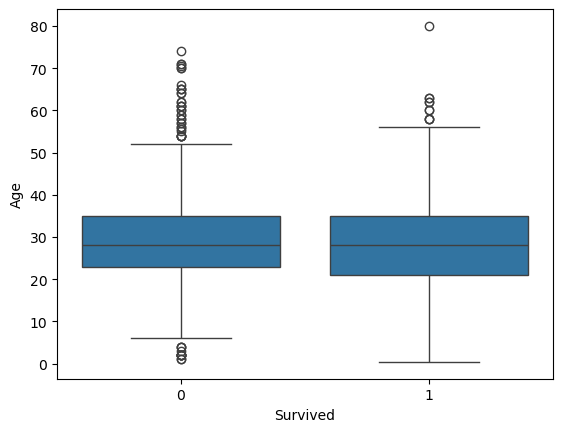

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Survived", y="Age")
plt.show()

In [48]:
df["Age_group"] = df["Age"].apply(
    lambda x: "Child" if x < 18 else "Adult"
)

pd.crosstab(
    df["Age_group"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Age_group,,
Adult,0.638817,0.361183
Child,0.460177,0.539823


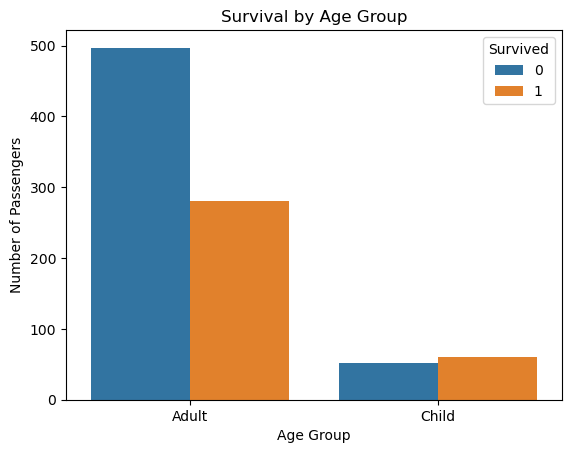

In [49]:
sns.countplot(data=df, x="Age_group", hue="Survived")
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.show()

Comparing Fare Vrs Survival

In [50]:
df.groupby("Survived")["Passenger_fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


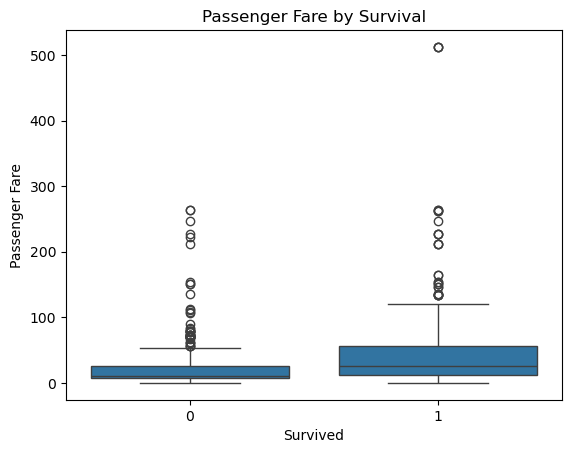

In [51]:
sns.boxplot(data=df, x="Survived", y="Passenger_fare")
plt.title("Passenger Fare by Survival")
plt.xlabel("Survived")
plt.ylabel("Passenger Fare")
plt.show()

In [53]:
#Checking whether fare price correlates with ticket class
df.groupby(["Ticket_class", "Survived"])["Passenger_fare"].median()

Ticket_class  Survived
1             0           44.7500
              1           77.9583
2             0           13.0000
              1           21.0000
3             0            8.0500
              1            8.5167
Name: Passenger_fare, dtype: float64

Comparing Family Size and Survival

In [54]:
df.groupby("Survived")["SibSp"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,0.553734,1.288399,0.0,0.0,0.0,1.0,8.0
1,342.0,0.473684,0.708688,0.0,0.0,0.0,1.0,4.0


In [55]:
pd.crosstab(
    df["SibSp"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
SibSp,,
0,0.654605,0.345395
1,0.464115,0.535885
2,0.535714,0.464286
3,0.750000,0.250000
4,0.833333,0.166667
5,1.000000,0.000000
8,1.000000,0.000000


No_Children_Siblings_onboard Vrs Survival

In [56]:
pd.crosstab(
    df["No_Children_Siblings_onboard"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
No_Children_Siblings_onboard,,
0,0.656342,0.343658
1,0.449153,0.550847
2,0.500000,0.500000
3,0.400000,0.600000
4,1.000000,0.000000
5,0.800000,0.200000
6,1.000000,0.000000


Creating a family size variable

In [57]:
df["Family_size"] = (
    df["SibSp"] +
    df["No_Children_Siblings_onboard"] +
    1
)

In [58]:
df.groupby("Survived")["Family_size"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,1.883424,1.830669,1.0,1.0,1.0,2.0,11.0
1,342.0,1.938596,1.186076,1.0,1.0,2.0,3.0,7.0


In [59]:
df["Family_size_group"] = pd.cut(
    df["Family_size"],
    bins=[0, 1, 4, 7, 11],
    labels=["Alone", "Small", "Medium", "Large"]
)

In [60]:
pd.crosstab(
    df["Family_size_group"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Family_size_group,,
Alone,0.696462,0.303538
Small,0.421233,0.578767
Medium,0.795918,0.204082
Large,1.000000,0.000000


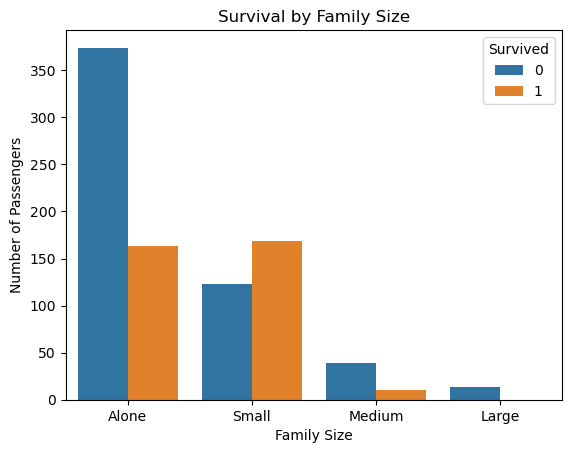

In [61]:
sns.countplot(
    data=df,
    x="Family_size_group",
    hue="Survived"
)

plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()

In [62]:
numeric_cols = [
    "Survived",
    "Ticket_class",
    "Age",
    "SibSp",
    "No_Children_Siblings_onboard",
    "Passenger_fare",
    "Family_size"
]

df[numeric_cols].corr()

,Survived,Ticket_class,Age,SibSp,No_Children_Siblings_onboard,Passenger_fare,Family_size
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Ticket_class,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
No_Children_Siblings_onboard,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Passenger_fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
Family_size,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


In [63]:
df.columns

Index(['Passenger_ID', 'Survived', 'Ticket_class', 'Name', 'Sex', 'Age',
       'SibSp', 'No_Children_Siblings_onboard', 'Ticket_number',
       'Passenger_fare', 'Cabin_no', 'Port_of_Embarkation', 'Age_missing',
       'Cabin_missing', 'Cabin_deck', 'Age_group', 'Family_size',
       'Family_size_group'],
      dtype='object')

Feature Engineering

In [64]:
features = [
    "Ticket_class",
    "Sex",
    "Age",
    "Age_missing",
    "SibSp",
    "No_Children_Siblings_onboard",
    "Passenger_fare",
    "Port_of_Embarkation",
    "Cabin_missing",
    "Cabin_deck",
    "Family_size"
]

In [65]:
X = df[features]
y = df["Survived"]

In [66]:
X.head()

,Ticket_class,Sex,Age,Age_missing,SibSp,No_Children_Siblings_onboard,Passenger_fare,Port_of_Embarkation,Cabin_missing,Cabin_deck,Family_size
0,3,male,22.0,0,1,0,7.2500,S,1,Unknown,2
1,1,female,38.0,0,1,0,71.2833,C,0,C,2
2,3,female,26.0,0,0,0,7.9250,S,1,Unknown,1
3,1,female,35.0,0,1,0,53.1000,S,0,C,2
4,3,male,35.0,0,0,0,8.0500,S,1,Unknown,1


In [67]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [68]:
X_encoded = pd.get_dummies(
    X,
    columns=["Sex", "Port_of_Embarkation", "Cabin_deck"],
    drop_first=True
)

In [69]:
X_encoded.head()

,Ticket_class,Age,Age_missing,SibSp,No_Children_Siblings_onboard,Passenger_fare,Cabin_missing,Family_size,Sex_male,Port_of_Embarkation_Q,Port_of_Embarkation_S,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_T,Cabin_deck_Unknown
0,3,22.0,0,1,0,7.2500,1,2,True,False,True,False,False,False,False,False,False,False,True
1,1,38.0,0,1,0,71.2833,0,2,False,False,False,False,True,False,False,False,False,False,False
2,3,26.0,0,0,0,7.9250,1,1,False,False,True,False,False,False,False,False,False,False,True
3,1,35.0,0,1,0,53.1000,0,2,False,False,True,False,True,False,False,False,False,False,False
4,3,35.0,0,0,0,8.0500,1,1,True,False,True,False,False,False,False,False,False,False,True


In [70]:
bool_cols = X_encoded.select_dtypes(include="bool").columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

In [71]:
X_encoded.dtypes

Ticket_class                      int64
Age                             float64
Age_missing                       int32
SibSp                             int64
No_Children_Siblings_onboard      int64
Passenger_fare                  float64
Cabin_missing                     int32
Family_size                       int64
Sex_male                          int32
Port_of_Embarkation_Q             int32
Port_of_Embarkation_S             int32
Cabin_deck_B                      int32
Cabin_deck_C                      int32
Cabin_deck_D                      int32
Cabin_deck_E                      int32
Cabin_deck_F                      int32
Cabin_deck_G                      int32
Cabin_deck_T                      int32
Cabin_deck_Unknown                int32
dtype: object

In [74]:
X_encoded.head()

,Ticket_class,Age,Age_missing,SibSp,No_Children_Siblings_onboard,Passenger_fare,Cabin_missing,Family_size,Sex_male,Port_of_Embarkation_Q,Port_of_Embarkation_S,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_T,Cabin_deck_Unknown
0,3,22.0,0,1,0,7.2500,1,2,1,0,1,0,0,0,0,0,0,0,1
1,1,38.0,0,1,0,71.2833,0,2,0,0,0,0,1,0,0,0,0,0,0
2,3,26.0,0,0,0,7.9250,1,1,0,0,1,0,0,0,0,0,0,0,1
3,1,35.0,0,1,0,53.1000,0,2,0,0,1,0,1,0,0,0,0,0,0
4,3,35.0,0,0,0,8.0500,1,1,1,0,1,0,0,0,0,0,0,0,1


Model Training Using the Training Dataset

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)

Training features: (712, 19)
Validation features: (179, 19)
Training target: (712,)
Validation target: (179,)


In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [78]:
y_pred = model.predict(X_val)

In [79]:
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0], dtype=int64)

In [80]:
y_val[:10].values

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0], dtype=int64)

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print(cm)

[[98 12]
 [22 47]]


Model Evaluation

In [83]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Ticket_class,-0.807000
1,Age,-0.039922
2,Age_missing,-0.355461
3,SibSp,-0.151727
4,No_Children_Siblings_onboard,0.008745
5,Passenger_fare,0.002617
6,Cabin_missing,-0.330827
7,Family_size,-0.107823
8,Sex_male,-2.572858
9,Port_of_Embarkation_Q,0.359489


In [ ]:
#Dropping the "Cabin_deck_Unknown" column as it is not informative for the model
X_encoded = X_encoded.drop(columns=["Cabin_deck_Unknown"])

In [85]:
#Running split again
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [87]:
y_pred = model.predict(X_val)

In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [89]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
14,Cabin_deck_E,0.831398
15,Cabin_deck_F,0.686286
13,Cabin_deck_D,0.649102
9,Port_of_Embarkation_Q,0.362186
4,No_Children_Siblings_onboard,0.024583
5,Passenger_fare,0.002627
1,Age,-0.039797
7,Family_size,-0.122153
3,SibSp,-0.137074
12,Cabin_deck_C,-0.186128


Investigating the performance of the Decision Tree model

In [90]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [92]:
tree_pred = tree_model.predict(X_val)

In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_val, tree_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.73      0.65      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



In [94]:
print("Training accuracy:", tree_model.score(X_train, y_train))
print("Validation accuracy:", tree_model.score(X_val, y_val))

Training accuracy: 0.9859550561797753
Validation accuracy: 0.770949720670391


In [95]:
tree_model_2 = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model_2.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [97]:
tree_pred_2 = tree_model_2.predict(X_val)

In [98]:
print(classification_report(y_val, tree_pred_2))

              precision    recall  f1-score   support

           0       0.76      0.94      0.84       110
           1       0.84      0.54      0.65        69

    accuracy                           0.78       179
   macro avg       0.80      0.74      0.75       179
weighted avg       0.79      0.78      0.77       179



In [99]:
print("Training accuracy:", tree_model_2.score(X_train, y_train))
print("Validation accuracy:", tree_model_2.score(X_val, y_val))

Training accuracy: 0.8384831460674157
Validation accuracy: 0.7821229050279329


Using a simpple tree to test performance

In [100]:
tree_model_3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model_3.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [101]:
tree_pred_3 = tree_model_3.predict(X_val)

In [102]:
print(classification_report(y_val, tree_pred_3))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [103]:
print("Training accuracy:", tree_model_3.score(X_train, y_train))
print("Validation accuracy:", tree_model_3.score(X_val, y_val))

Training accuracy: 0.8286516853932584
Validation accuracy: 0.8044692737430168


In [104]:
from sklearn.metrics import confusion_matrix

tree_cm_3 = confusion_matrix(y_val, tree_pred_3)
print(tree_cm_3)

[[99 11]
 [24 45]]


Training the Data on Random Forests

In [105]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [106]:
rf_pred = rf_model.predict(X_val)

In [107]:
print(classification_report(y_val, rf_pred))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



Checking for Overfitting

In [108]:
print("Training accuracy:", rf_model.score(X_train, y_train))
print("Validation accuracy:", rf_model.score(X_val, y_val))

Training accuracy: 0.9859550561797753
Validation accuracy: 0.7821229050279329


In [109]:
rf_model_2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model_2.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

Retraining the Model

In [110]:
rf_pred_2 = rf_model_2.predict(X_val)

In [111]:
print(classification_report(y_val, rf_pred_2))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.77      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



In [112]:
print("Training accuracy:", rf_model_2.score(X_train, y_train))
print("Validation accuracy:", rf_model_2.score(X_val, y_val))

Training accuracy: 0.8707865168539326
Validation accuracy: 0.7877094972067039


Checking the reliability of the generalisation using cross-fold validation

In [113]:
from sklearn.model_selection import cross_val_score

logistic_cv = cross_val_score(
    model,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(logistic_cv)
print("Mean CV accuracy:", logistic_cv.mean())

[0.7877095  0.79213483 0.78089888 0.79775281 0.81460674]
Mean CV accuracy: 0.794620551126734


In [114]:
tree_cv = cross_val_score(
    tree_model_3,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(tree_cv)
print("Mean CV accuracy:", tree_cv.mean())

[0.81005587 0.81460674 0.80337079 0.78089888 0.8258427 ]
Mean CV accuracy: 0.8069549934090766


In [115]:
rf_cv = cross_val_score(
    rf_model_2,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(rf_cv)
print("Mean CV accuracy:", rf_cv.mean())

[0.77094972 0.82022472 0.86516854 0.79775281 0.84831461]
Mean CV accuracy: 0.8204820789655388


Doing a 5 fold macro F1 to identify how well each model identifies each class.

In [116]:
logistic_f1_cv = cross_val_score(
    model,
    X_encoded,
    y,
    cv=5,
    scoring="f1_macro"
)

print(logistic_f1_cv)
print("Mean CV macro F1:", logistic_f1_cv.mean())

[0.77712975 0.7765564  0.76862314 0.77888199 0.80194882]
Mean CV macro F1: 0.780628019642547


In [117]:
tree_f1_cv = cross_val_score(
    tree_model_3,
    X_encoded,
    y,
    cv=5,
    scoring="f1_macro"
)

print(tree_f1_cv)
print("Mean CV macro F1:", tree_f1_cv.mean())

[0.79842342 0.80421958 0.78863444 0.74215355 0.81026717]
Mean CV macro F1: 0.7887396305648602


In [118]:
rf_f1_cv = cross_val_score(
    rf_model_2,
    X_encoded,
    y,
    cv=5,
    scoring="f1_macro"
)

print(rf_f1_cv)
print("Mean CV macro F1:", rf_f1_cv.mean())

[0.75320308 0.80200222 0.85258799 0.7677251  0.83230399]
Mean CV macro F1: 0.801564476578946


We have selected the Random Forest model Evaluation. Now we are tuning the hyperparameteres.


In [119]:
rf_model_3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model_3.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [120]:
rf_cv_2 = cross_val_score(
    rf_model_3,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(rf_cv_2)
print("Mean CV accuracy:", rf_cv_2.mean())

[0.77094972 0.8258427  0.86516854 0.80337079 0.84269663]
Mean CV accuracy: 0.8216056744711568


In [121]:
rf_model_4 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=4,
    random_state=42
)

rf_model_4.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [122]:
rf_cv_4 = cross_val_score(
    rf_model_4,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(rf_cv_4)
print("Mean CV accuracy:", rf_cv_4.mean())

[0.77653631 0.82022472 0.86516854 0.79213483 0.85955056]
Mean CV accuracy: 0.8227229929069111


In [123]:
rf_model_5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=8,
    random_state=42
)

rf_model_5.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [124]:
rf_cv_8 = cross_val_score(
    rf_model_5,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(rf_cv_8)
print("Mean CV accuracy:", rf_cv_8.mean())

[0.77653631 0.81460674 0.85955056 0.79775281 0.83146067]
Mean CV accuracy: 0.8159814198732033


The performance of the Random Forest model with min_samples_leaf=4 seems to be the best among the tested configurations, balancing accuracy and generalization. 

Now we are testing the number of trees

In [125]:
rf_model_6 = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=4,
    random_state=42
)

rf_model_6.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [126]:
rf_cv_200 = cross_val_score(
    rf_model_6,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(rf_cv_200)
print("Mean CV accuracy:", rf_cv_200.mean())

[0.78212291 0.8258427  0.85393258 0.79775281 0.85393258]
Mean CV accuracy: 0.8227167158370472


In [127]:
rf_f1_cv_4 = cross_val_score(
    rf_model_4,
    X_encoded,
    y,
    cv=5,
    scoring="f1_macro"
)

print(rf_f1_cv_4)
print("Mean CV macro F1:", rf_f1_cv_4.mean())

[0.75506294 0.80200222 0.85258799 0.76236695 0.8480347 ]
Mean CV macro F1: 0.8040109612669445


Assessing Feature Importance

In [128]:
feature_importance = pd.Series(
    rf_model_4.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print(feature_importance)

Sex_male                        0.395376
Passenger_fare                  0.146697
Cabin_missing                   0.104614
Ticket_class                    0.093755
Age                             0.080398
Family_size                     0.057453
SibSp                           0.027685
Port_of_Embarkation_S           0.022843
No_Children_Siblings_onboard    0.018237
Cabin_deck_C                    0.010503
Cabin_deck_D                    0.010425
Cabin_deck_E                    0.009803
Port_of_Embarkation_Q           0.009158
Age_missing                     0.007488
Cabin_deck_B                    0.004648
Cabin_deck_F                    0.000643
Cabin_deck_G                    0.000275
Cabin_deck_T                    0.000000
dtype: float64


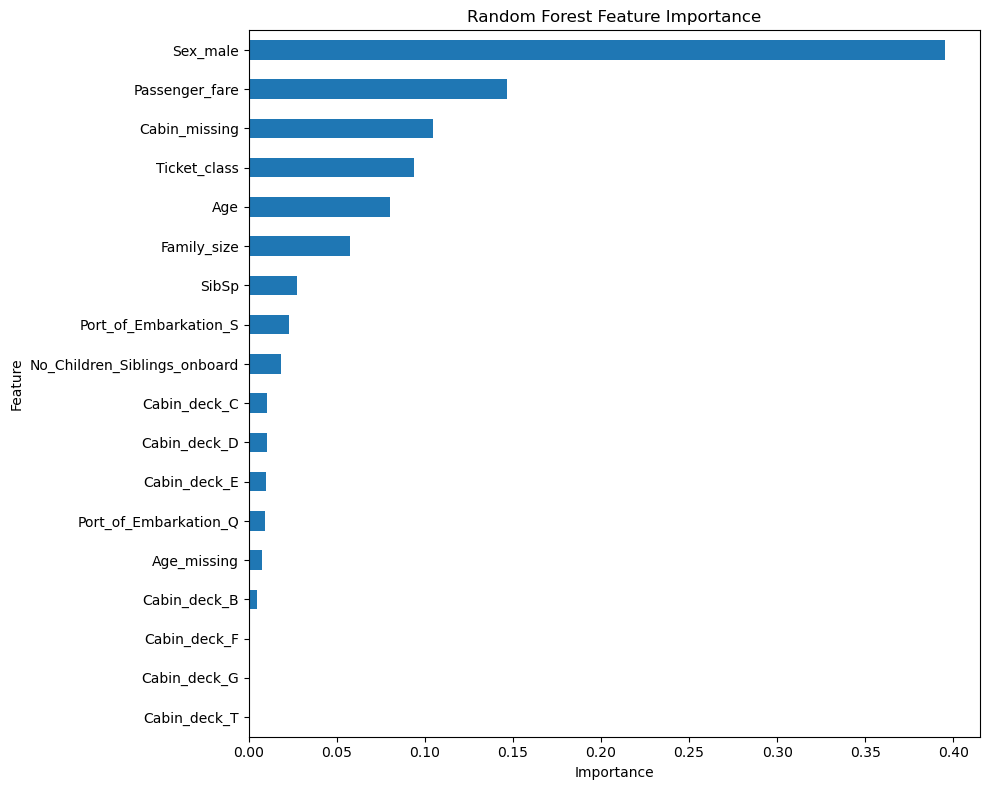

In [130]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [131]:
rf_pred_4 = rf_model_4.predict(X_val)

print(classification_report(y_val, rf_pred_4))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.77      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



In [132]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_val, rf_pred_4)

print(rf_cm)

[[97 13]
 [25 44]]


Pipeline Preparation

The features and target variable are separated before building the preprocessing and modeling pipeline. The pipeline will ensure that preprocessing is applied consistently during model training, cross-validation, and later prediction on unseen data.

In [133]:
features = [
    "Ticket_class",
    "Sex",
    "Age",
    "Age_missing",
    "SibSp",
    "No_Children_Siblings_onboard",
    "Passenger_fare",
    "Port_of_Embarkation",
    "Cabin_missing",
    "Cabin_deck",
    "Family_size"
]

X_raw = df[features]
y = df["Survived"]

In [134]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "Ticket_class",
    "Age",
    "Age_missing",
    "SibSp",
    "No_Children_Siblings_onboard",
    "Passenger_fare",
    "Cabin_missing",
    "Family_size"
]

categorical_features = [
    "Sex",
    "Port_of_Embarkation",
    "Cabin_deck"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [136]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            min_samples_leaf=4,
            random_state=42
        ))
    ]
)

In [137]:
rf_pipeline_cv = cross_val_score(
    rf_pipeline,
    X_raw,
    y,
    cv=5,
    scoring="accuracy"
)

print(rf_pipeline_cv)
print("Mean CV accuracy:", rf_pipeline_cv.mean())

[0.81005587 0.8258427  0.83146067 0.78651685 0.82022472]
Mean CV accuracy: 0.8148201619484026


The earlier 82.27% calculation used X_encoded, which had already been one-hot encoded before cross-validation.

The new pipeline performs the encoding separately inside each fold, which is methodologically cleaner and avoids information from the validation fold influencing preprocessing.

So I would trust the 81.48% estimate more than the previous 82.27%.

And importantly, this doesn't mean the model suddenly became worse. It means we now have a more realistic estimate of how it performs on unseen data.

check macro F1 using the same pipeline.

In [138]:
rf_pipeline_f1 = cross_val_score(
    rf_pipeline,
    X_raw,
    y,
    cv=5,
    scoring="f1_macro"
)

print(rf_pipeline_f1)
print("Mean CV macro F1:", rf_pipeline_f1.mean())

[0.79842342 0.81395192 0.81939935 0.75248829 0.80482456]
Mean CV macro F1: 0.7978175092067102


In [140]:
X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [141]:
rf_pipeline.fit(X_raw_train, y_raw_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Ticket_class','Sex','Age',...,'Cabin_missing','Cabin_deck','Family_size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [142]:
rf_pipeline_pred = rf_pipeline.predict(X_raw_val)

print(classification_report(y_raw_val, rf_pipeline_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [143]:
test_df = pd.read_csv("test.csv")

test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [144]:
print(test_df.shape)
print(test_df.columns.tolist())

(418, 11)
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [145]:
test_df = test_df.rename(columns={
    "PassengerId": "Passenger_ID",
    "Pclass": "Ticket_class",
    "Parch": "No_Children_Siblings_onboard",
    "Ticket": "Ticket_number",
    "Fare": "Passenger_fare",
    "Cabin": "Cabin_no",
    "Embarked": "Port_of_Embarkation"
})

test_df.head()

,Passenger_ID,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [146]:
test_df["Age_missing"] = test_df["Age"].isna().astype(int)

test_df["Cabin_missing"] = test_df["Cabin_no"].isna().astype(int)

test_df[["Age", "Age_missing", "Cabin_no", "Cabin_missing"]].head()

,Age,Age_missing,Cabin_no,Cabin_missing
0,34.5,0,NaN,1
1,47.0,0,NaN,1
2,62.0,0,NaN,1
3,27.0,0,NaN,1
4,22.0,0,NaN,1


In [147]:
test_df["Cabin_deck"] = test_df["Cabin_no"].str[0].fillna("Unknown")

test_df[["Cabin_no", "Cabin_deck"]].head()

,Cabin_no,Cabin_deck
0,NaN,Unknown
1,NaN,Unknown
2,NaN,Unknown
3,NaN,Unknown
4,NaN,Unknown


In [148]:
test_df["Family_size"] = (
    test_df["SibSp"] +
    test_df["No_Children_Siblings_onboard"] +
    1
)

test_df[["SibSp", "No_Children_Siblings_onboard", "Family_size"]].head()

,SibSp,No_Children_Siblings_onboard,Family_size
0,0,0,1
1,1,0,2
2,0,0,1
3,0,0,1
4,1,1,3


In [150]:
print(test_df[[
    "Age",
    "Port_of_Embarkation"
]].isna().sum())

Age                    86
Port_of_Embarkation     0
dtype: int64


In [151]:
test_df["Age"] = test_df["Age"].fillna(df["Age"].median())

print(test_df["Age"].isna().sum())

0


In [152]:
test_features = [
    "Ticket_class",
    "Sex",
    "Age",
    "Age_missing",
    "SibSp",
    "No_Children_Siblings_onboard",
    "Passenger_fare",
    "Port_of_Embarkation",
    "Cabin_missing",
    "Cabin_deck",
    "Family_size"
]

X_test = test_df[test_features]

print(X_test.shape)
print(X_test.columns.tolist())

(418, 11)
['Ticket_class', 'Sex', 'Age', 'Age_missing', 'SibSp', 'No_Children_Siblings_onboard', 'Passenger_fare', 'Port_of_Embarkation', 'Cabin_missing', 'Cabin_deck', 'Family_size']


In [153]:
test_predictions = rf_pipeline.predict(X_test)

print(test_predictions[:20])
print("Number of predictions:", len(test_predictions))

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]
Number of predictions: 418


In [154]:
print(pd.Series(test_predictions).value_counts())

0    261
1    157
Name: count, dtype: int64


In [155]:
submission = pd.DataFrame({
    "PassengerId": test_df["Passenger_ID"],
    "Survived": test_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [156]:
print(submission.shape)
print(submission.columns.tolist())
print(submission["Survived"].value_counts())

(418, 2)
['PassengerId', 'Survived']
Survived
0    261
1    157
Name: count, dtype: int64
